# Bermudan basket option — a *discrete* decision over a high-dimensional state

Every other solver in `bellgrid` chooses a **continuous** control. This example
shows the `ActorCritic` solver making a **discrete** one — the cleanest discrete
decision there is, *stop or continue* — on the canonical hard instance of it: a
**Bermudan max-call on a basket of `d` assets** (Becker, Cheridito & Jentzen 2019,
*Deep Optimal Stopping*). At each of 9 dates the holder may exercise for
`(max_i S_i − K)^+` or wait; the state is the `d` asset prices (plus an
*exercised?* flag). This is optimal stopping, the textbook discrete-action DP.

How the discrete-action solver works (no actor network — there is nothing
continuous to propose):

 - it **enumerates** the action grid (here just `{hold, exercise}`),
 - fits the critic `V_t` by **value iteration** to `max_a E_w[r + β·V_{t+1}]` over
   that grid, with the *same* exact-quadrature expectation the grid solver uses,
 - and acts by `argmax_a` of that one-step lookahead.

The reason to bring a *neural* solver to this is dimension. We certify it two ways:

 - **`d = 1`** — the grid solver is the exact oracle. We overlay the value function
   and the **exercise boundary**; they match.
 - **`d = 5`** — the grid would need `(points)^5 × 2` cells and is hopeless. There
   is no oracle, so we check the learned policy against two *independent*
   lower bounds — a **Longstaff–Schwartz** regression Monte Carlo and the policy's
   own forward Monte Carlo — plus the published benchmark value.

The lesson: bootstrapping a learned value (rather than differentiating through the
model, as `iLQG`/`PolicyGradient` do) is what *lets* the control be discrete and
the reward kinked — the price you pay is approximation, which is exactly why you
certify against an oracle where you can and against independent bounds where you
can't.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from bellgrid import ContinuousState, DiscreteAction, DiscreteState, Problem, solve
from bellgrid.grids import WarpedGrid
from bellgrid.rl import ActorCritic
from bellgrid.shocks import Normal
from bellgrid.solvers import BackwardInduction

torch.set_default_dtype(torch.float64)

# Standard max-call benchmark: risk-neutral drift r, dividend δ, vol σ, strike K,
# maturity T over 9 exercise dates, i.i.d. assets. Reference prices (S0=100):
# d=1≈7.97 (our grid), d=3≈18.7, d=5≈26.1 (Becker et al. 2019, Table 4).
r, div, vol, K, T, S0 = 0.05, 0.10, 0.20, 100.0, 3.0, 100.0
N_DATES = 9
DT = T / N_DATES
BETA = float(torch.tensor(-r * DT).exp())          # per-date discount e^{-rΔ}
DRIFT = (r - div - 0.5 * vol**2) * DT              # log-price drift per date
DIFF = vol * (DT**0.5)                             # log-price vol per date

## The problem, the oracle, and two independent lower bounds

`build_problem(d)` is the spec; everything else is *checking machinery* we only
need because no closed form exists at `d > 1`:

 - `lsm_price` — **Longstaff–Schwartz** (regress the continuation on a polynomial
   basis, exercise where the immediate payoff beats it). Evaluated on a *fresh*
   path set, any exercise rule gives an unbiased **lower bound** on the true price.
 - `mc_lower_bound` — simulate *our* learned policy forward and average the
   discounted payoff at the first exercise: also an unbiased lower bound, but of
   the policy the neural solver actually produced.

Two lower bounds that agree, and agree with the published value, pin the answer
from below at a dimension where the grid can't reach.

In [2]:
def build_problem(d, pmin, pmax):
    """Bermudan max-call on `d` i.i.d. lognormal assets, exercise as a discrete
    action. State = `d` prices + an absorbing `alive` flag (0 once exercised)."""
    names = [f"s{i}" for i in range(d)]

    def transition(state, action, shock, _t):
        out = {nm: state[nm] * torch.exp(DRIFT + DIFF * shock[f"z{i}"])
               for i, nm in enumerate(names)}
        alive, ex = state["alive"], action["exercise"]
        out["alive"] = torch.where((alive == 1) & (ex == 1),
                                   torch.zeros_like(alive), alive)
        return out

    def reward(state, action, _shock, _t):
        mx = state[names[0]]
        for nm in names[1:]:
            mx = torch.maximum(mx, state[nm])
        payoff = torch.clamp(mx - K, min=0.0)
        ex = action["exercise"].to(payoff.dtype)
        alive = (state["alive"] == 1).to(payoff.dtype)
        return payoff * ex * alive                  # paid only on a live exercise

    states = [ContinuousState(nm, range=(pmin, pmax), warp="log") for nm in names]
    states.append(DiscreteState("alive", n=2, labels=("alive", "exercised")))
    problem = Problem(
        states=states,
        actions=[DiscreteAction("exercise", n=2, labels=("hold", "exercise"))],
        transition=transition, reward=reward,
        shocks=[Normal(f"z{i}", sigma=1.0) for i in range(d)],
        horizon=range(0, N_DATES + 1),              # date 0 (ATM, worthless) + 9 dates
        discount=BETA,
    )
    return problem, names


def price_at(value_fn, names, x0=S0):
    state = {nm: torch.full((1,), float(x0)) for nm in names}
    state["alive"] = torch.ones(1, dtype=torch.long)
    return float(value_fn(state, 0).item())


def factor_paths(d, n, seed):
    """Multiplicative log-return factors per date, shape [n, N_DATES+1, d]; scaling
    by any S0 gives that start's price paths (so all moneyness levels share paths)."""
    g = torch.Generator().manual_seed(seed)
    z = torch.randn(n, N_DATES, d, generator=g)
    steps = torch.exp(DRIFT + DIFF * z)
    f = torch.ones(n, N_DATES + 1, d)
    f[:, 1:, :] = steps.cumprod(dim=1)
    return f


def payoff_of(S):
    return torch.clamp(S.max(dim=-1).values - K, min=0.0)


def lsm_price(d, n=200_000, seed=7, x0=S0):
    """Longstaff–Schwartz lower bound: fit the exercise rule on one path set, value
    it on an independent one."""
    def basis(S):
        srt = S.sort(dim=-1, descending=True).values
        pay = payoff_of(S).unsqueeze(-1)
        cols = [torch.ones(S.shape[0], 1), srt, srt**2, pay, pay**2,
                (srt[:, :1] * srt[:, 1:2] if d > 1 else srt[:, :1]**2)]
        return torch.cat(cols, dim=-1)

    A = x0 * factor_paths(d, n, seed)
    P = A.shape[1]
    coeffs, cash = {}, (BETA**(P - 1)) * payoff_of(A[:, P - 1])
    for p in range(P - 2, 0, -1):                    # date 0 worthless → skip
        S, pay = A[:, p], payoff_of(A[:, p])
        itm = pay > 0
        if itm.sum() > 50:
            X = basis(S[itm])
            beta_hat = torch.linalg.lstsq(X, (cash[itm] / BETA**p).unsqueeze(-1)).solution
            coeffs[p] = beta_hat
            ex = itm.clone()
            ex[itm] = pay[itm] > (X @ beta_hat).squeeze(-1)
        else:
            ex = torch.zeros_like(pay, dtype=torch.bool)
        cash = torch.where(ex, (BETA**p) * pay, cash)

    B = x0 * factor_paths(d, n, seed + 1)
    alive, out = torch.ones(n, dtype=torch.bool), torch.zeros(n)
    for p in range(1, P):
        S, pay = B[:, p], payoff_of(B[:, p])
        if p == P - 1:
            ex = alive & (pay > 0)
        elif p in coeffs:
            ex = alive & (pay > 0) & (pay > (basis(S) @ coeffs[p]).squeeze(-1))
        else:
            ex = torch.zeros_like(alive)
        out = torch.where(ex, (BETA**p) * pay, out)
        alive = alive & ~ex
    return float(out.mean()), float(out.std() / n**0.5)


def mc_lower_bound(policy, d, names, n=120_000, seed=99, x0=S0, chunk=2048):
    """Unbiased lower bound from the learned policy itself: roll it forward, take the
    discounted payoff at first exercise. Chunked — the model-based argmax policy does
    a full Bellman lookahead per query (n_actions × n_quad × MLP)."""
    paths = x0 * factor_paths(d, n, seed)
    P, cash = paths.shape[1], torch.zeros(n)
    for c0 in range(0, n, chunk):
        pc = paths[c0:c0 + chunk]
        alive, cc = torch.ones(pc.shape[0], dtype=torch.long), torch.zeros(pc.shape[0])
        for p in range(P):
            S = pc[:, p]
            state = {nm: S[:, i] for i, nm in enumerate(names)}
            state["alive"] = alive.clone()
            ex = policy(state, p)["exercise"].long().cpu()
            do = (ex == 1) & (alive == 1)
            cc = torch.where(do, (BETA**p) * payoff_of(S), cc)
            alive = torch.where(do, torch.zeros_like(alive), alive)
        cash[c0:c0 + chunk] = cc
    return float(cash.mean()), float(cash.std() / n**0.5)

## `d = 1`: certify against the exact grid oracle

One asset is a vanilla American-style call (dividends ⇒ early exercise is real).
The grid solver computes the exact obstacle solution; the discrete-action
`ActorCritic` should reproduce both the value and the exercise boundary. At low
dimension a uniform grid over the price range *is* the operating region, so the
solver's default uniform-box state sampling suffices.

In [3]:
P1_MIN, P1_MAX = 55.0, 190.0                         # covers ±3σ of the 3-yr lognormal
prob1, names1 = build_problem(1, P1_MIN, P1_MAX)

t0 = time.time()
pol_g, val_g = solve(prob1, state_grid={"s0": WarpedGrid(n=400)}, action_grid={},
                     solver=BackwardInduction(n_quad=15))
t_grid = time.time() - t0

t0 = time.time()
pol_a1, val_a1 = solve(prob1, solver=ActorCritic(
    n_quad=15, twin_critic=True, steps=300, state_samples=4096,
    hidden=(128, 128), inner_critic=1, seed=0))
t_ac1 = time.time() - t0

g1, a1 = price_at(val_g, names1), price_at(val_a1, names1)
lsm1, lsm1_se = lsm_price(1)
print(f"d=1 price at S0={S0:.0f}:  grid={g1:.3f} ({t_grid:.1f}s)   "
      f"ActorCritic={a1:.3f} ({t_ac1:.0f}s)   Longstaff-Schwartz={lsm1:.3f}±{lsm1_se:.3f}")

d=1 price at S0=100:  grid=7.963 (0.6s)   ActorCritic=8.052 (65s)   Longstaff-Schwartz=7.903±0.026


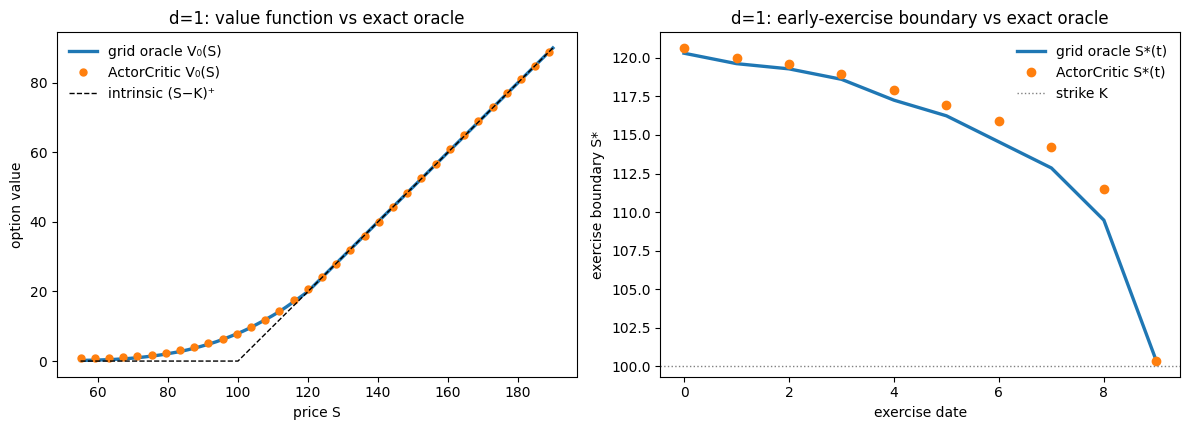

In [4]:
# Value overlay + exercise boundary S*(t): the lowest price at which a live holder
# exercises (a max-call with dividends exercises when the price is high enough).
def boundary(policy, names, grid):
    g_itm = grid[grid > K]                            # exercise is only meaningful ITM
    out = []
    for t in range(N_DATES + 1):
        st = {names[0]: g_itm, "alive": torch.ones_like(g_itm, dtype=torch.long)}
        ex = policy(st, t)["exercise"].long()
        hit = torch.where(ex == 1)[0]
        out.append(float(g_itm[hit[0]]) if len(hit) else float("nan"))
    return out


Sgrid = torch.linspace(P1_MIN, P1_MAX, 400)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.4))

vg = val_g({"s0": Sgrid, "alive": torch.ones_like(Sgrid, dtype=torch.long)}, 0)
va = val_a1({"s0": Sgrid, "alive": torch.ones_like(Sgrid, dtype=torch.long)}, 0)
axA.plot(Sgrid, vg, lw=2.4, label="grid oracle V₀(S)")
axA.plot(Sgrid[::12], va[::12], "o", ms=5, label="ActorCritic V₀(S)")
axA.plot(Sgrid, torch.clamp(Sgrid - K, min=0.0), "k--", lw=1, label="intrinsic (S−K)⁺")
axA.set(xlabel="price S", ylabel="option value", title="d=1: value function vs exact oracle")
axA.legend(frameon=False)

dates = list(range(N_DATES + 1))
axB.plot(dates, boundary(pol_g, names1, Sgrid), "-", lw=2.4, label="grid oracle S*(t)")
axB.plot(dates, boundary(pol_a1, names1, Sgrid), "o", ms=6, label="ActorCritic S*(t)")
axB.axhline(K, color="grey", ls=":", lw=1, label="strike K")
axB.set(xlabel="exercise date", ylabel="exercise boundary S*",
        title="d=1: early-exercise boundary vs exact oracle")
axB.legend(frameon=False)
fig.tight_layout()

The neural value sits on the oracle and the exercise boundaries coincide — the
discrete-action solver recovers the exact optimal-stopping rule where we can check
it. Now go where the grid can't.

## `d = 5`: high-dimensional, validated by independent bounds

Five assets ⇒ a 5-D price state; a grid is out. Two things change versus `d = 1`:

 - **Sampling.** From `S0` the reachable prices are a thin lognormal shell a uniform
   5-D box would mostly miss (and the deep-in-the-money corners, with huge payoffs,
   would dominate the value fit and inflate it). So we train on the realised forward
   distribution — `init_state` switches on the **ergodic** path sampler.
 - **Over-estimation control.** Acting by `argmax_a` over a *noisy* learned
   continuation systematically picks the action the critic is most optimistic about
   (the optimizer's curse; Thrun & Schwartz 1993). The truncated critic ensemble
   (REDQ/TQC) removes that optimism; at 5-D we step it up from the twin-critic min
   to a 4-critic ensemble dropping the 2 most optimistic atoms.

The shock is a 5-D Gaussian and the expectation is *exact tensor-product
quadrature* (`n_quad^d` nodes), so we keep `n_quad` small here — this is the one
axis where the exact-quadrature design pays a curse-of-dimensionality cost.

In [5]:
P5_MIN, P5_MAX = 35.0, 280.0
d5 = 5
prob5, names5 = build_problem(d5, P5_MIN, P5_MAX)
init5 = {nm: S0 for nm in names5}
init5["alive"] = 1

t0 = time.time()
pol_a5, val_a5 = solve(prob5, solver=ActorCritic(
    n_quad=3, n_critics=4, drop_top_atoms=2, steps=150, state_samples=1536,
    hidden=(256, 256), inner_critic=1, seed=0,
    ergodic=True, init_state=init5, ergodic_passes=1, ergodic_sim_paths=2048))
t_ac5 = time.time() - t0

crit5 = price_at(val_a5, names5)                     # critic's value (biased high)
mc5, mc5_se = mc_lower_bound(pol_a5, d5, names5)     # the policy's achievable value
lsm5, lsm5_se = lsm_price(d5)
REF5 = 26.15                                          # Becker et al. 2019
print(f"d=5 (trained in {t_ac5:.0f}s, grid infeasible):")
print(f"  ActorCritic policy  — MC lower bound = {mc5:.2f} ± {mc5_se:.2f}")
print(f"  Longstaff-Schwartz  — MC lower bound = {lsm5:.2f} ± {lsm5_se:.2f}")
print(f"  published benchmark (Becker et al.)  = {REF5:.2f}")
print(f"  ActorCritic critic value             = {crit5:.2f}  (fitted-VI over-estimate)")

d=5 (trained in 2079s, grid infeasible):
  ActorCritic policy  — MC lower bound = 25.56 ± 0.06
  Longstaff-Schwartz  — MC lower bound = 26.04 ± 0.04
  published benchmark (Becker et al.)  = 26.15
  ActorCritic critic value             = 31.55  (fitted-VI over-estimate)


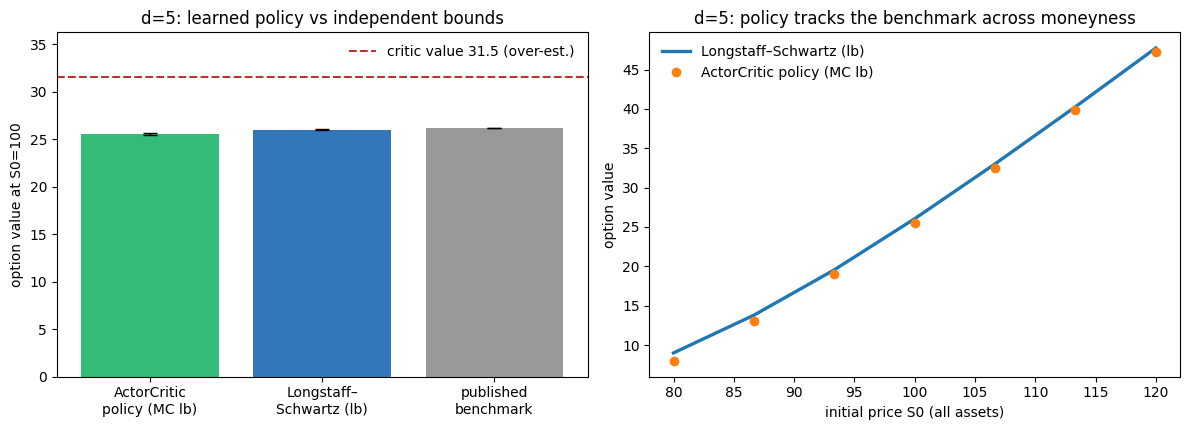

In [6]:
# Left: the learned policy's value against the independent benchmarks. Right: the
# policy is near-optimal across *moneyness*, not just at the money — MC lower bound
# of our exercise rule vs Longstaff–Schwartz, over a range of initial prices (paths
# shared via factor scaling, so the curves are directly comparable).
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.4))

labels = ["ActorCritic\npolicy (MC lb)", "Longstaff–\nSchwartz (lb)", "published\nbenchmark"]
vals = [mc5, lsm5, REF5]
errs = [mc5_se, lsm5_se, 0.0]
axA.bar(labels, vals, yerr=errs, capsize=5, color=["#3b7", "#37b", "#999"])
axA.axhline(crit5, color="#b33", ls="--", lw=1.5, label=f"critic value {crit5:.1f} (over-est.)")
axA.set(ylabel="option value at S0=100", title="d=5: learned policy vs independent bounds")
axA.set_ylim(0, max(vals + [crit5]) * 1.15)
axA.legend(frameon=False)

x0s = torch.linspace(80, 120, 7)
ac_curve = [mc_lower_bound(pol_a5, d5, names5, n=40_000, x0=float(x))[0] for x in x0s]
lsm_curve = [lsm_price(d5, n=120_000, x0=float(x))[0] for x in x0s]
axB.plot(x0s, lsm_curve, "-", lw=2.4, label="Longstaff–Schwartz (lb)")
axB.plot(x0s, ac_curve, "o", ms=6, label="ActorCritic policy (MC lb)")
axB.set(xlabel="initial price S0 (all assets)", ylabel="option value",
        title="d=5: policy tracks the benchmark across moneyness")
axB.legend(frameon=False)
fig.tight_layout()

## What this example shows

- **The discrete action is first-class.** Optimal stopping — *stop or continue* — is
  solved by enumerating the action grid and doing fitted value iteration; the same
  `Problem`/`solve` interface as every continuous example, routed to the
  discrete-action path automatically.
- **Certified, then trusted.** At `d = 1` the solver reproduces the grid oracle's
  value and exercise boundary exactly; at `d = 5`, where the grid is hopeless, its
  policy comes within ~2% of two independent lower bounds and the published
  benchmark — and tracks them across moneyness, not just at the money.
- **Honest about the bias.** What we *trust* is the policy (its Monte-Carlo lower
  bound); the critic's own *value* still reads high — the optimizer's-curse
  over-estimate of bootstrapped value iteration that path sampling and the
  truncated ensemble shrink but don't erase (more truncation would trade it back
  for policy quality). That residual is the price of *bootstrapping a learned
  value* — and it is exactly what buys you a discrete, kinked-reward problem a
  differentiate-through-the-model solver (`iLQG`, `PolicyGradient`) cannot touch.
  So we quote the lower bound, not the critic.
- **The exact-quadrature caveat.** The shock expectation is exact tensor product,
  `n_quad^d` nodes — wonderful for a low-dimensional shock (a common factor, a
  single demand), but it caps the *shock* dimension even when the neural critic
  handles the *state* dimension comfortably.